# 🌿 EDA · Eventos Kulturklik
**Proyecto Sustrai** — Análisis exploratorio de datos culturales del País Vasco

---


## 0. Configuración e importaciones

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Paleta Sustrai (oficial) ─────────────────────────────────────────────────
COLOR_AZUL    = '#29366d'   # Azul marino (Principal)
COLOR_CIRUELA = '#5e3d59'   # Ciruela oscuro
COLOR_MALVA   = '#7f557b'   # Malva
COLOR_CREMA   = '#e8eaca'   # Crema claro
BG_COLOR      = '#fcfffe'   # Fondo casi blanco

TITLE_COLOR = COLOR_AZUL
TEXT_COLOR  = COLOR_AZUL

PALETTE = [COLOR_AZUL, COLOR_CIRUELA, COLOR_MALVA, COLOR_CREMA,
           '#3d4f8a', '#7a5075', '#9b6e96', '#c4d4b0']

plt.rcParams['font.family']      = 'sans-serif'
plt.rcParams['font.sans-serif']  = ['Inter', 'Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif']
plt.rcParams['text.color']       = TEXT_COLOR
plt.rcParams.update({
    'figure.facecolor': BG_COLOR,
    'axes.facecolor':   BG_COLOR,
    'axes.edgecolor':   COLOR_AZUL,
    'axes.labelcolor':  COLOR_AZUL,
    'axes.titlecolor':  COLOR_AZUL,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.color':      COLOR_AZUL,
    'ytick.color':      COLOR_AZUL,
    'grid.color':       COLOR_CREMA,
    'grid.linewidth':   0.6,
    'figure.dpi':       110,
})

print("✅ Configuración cargada")


✅ Configuración cargada


## 1. Carga del dataset

In [34]:
df = pd.read_csv("..\data\eventos.csv")

PROV  = {48: "Bizkaia", 20: "Gipuzkoa", 1: "Araba/Álava"}
LANG  = {"ES":"Castellano","EU":"Euskera","VI":"Varios","EN":"Inglés",
         "VS":"Vasco/Cast.","OO":"Otros","FR":"Francés"}
MESES = {1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",
         7:"Jul",8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic"}

df["province"]   = df["provinceNoraCode"].map(PROV)
df["lang_label"] = df["language"].map(LANG)
df["mes_label"]  = df["month"].map(MESES)

print(f"Filas: {len(df):,}  |  Columnas: {df.shape[1]}")
df.head(3)


Filas: 2,744  |  Columnas: 37


,id_Kulturklik,type,typeEs,nameEs,startDate,endDate,publicationDate,language,openingHoursEs,sourceNameEs,...,subtipo,price_eur,is_free,year,month,weekday,is_weekend,province,lang_label,mes_label
0,2025072111423614,1,Concierto,Bilbao Orkestra Sinfonikoa (BOS): Cámara 10,2026-05-25 00:00:00+00:00,2026-05-25 00:00:00+00:00,2026-05-25T08:05:01Z,NaN,19:30,www.bilbaorkestra.eus,...,Otros,NaN,True,2026.0,5.0,Lunes,False,Bizkaia,NaN,May
1,2025072213252895,1,Concierto,"Euskadiko Orkestra: ""Bernaola / Mendelssohn"" (...",2026-05-25 00:00:00+00:00,2026-05-25 00:00:00+00:00,2026-05-15T14:35:48Z,NaN,19:30,euskadikoorkestra.eus,...,Otros,NaN,True,2026.0,5.0,Lunes,False,Araba/Álava,NaN,May
2,2025090511122854,6,Conferencia,"English book club (2025-2026): ""The Russia House""",2026-05-25 00:00:00+00:00,2026-05-25 00:00:00+00:00,2025-09-05T11:12:52Z,EN,19:00,kulturaetxea.araba.eus,...,Otros,NaN,True,2026.0,5.0,Lunes,False,Araba/Álava,Inglés,May


In [56]:
df["language"].unique()

array([nan, 'EN', 'ES', 'EU', 'VI', 'OO', 'VS', 'FR'], dtype=object)

In [57]:
df["lang_label"].unique()

array([nan, 'Inglés', 'Castellano', 'Euskera', 'Varios', 'Otros',
       'Vasco/Cast.', 'Francés'], dtype=object)

In [58]:
import pandas as pd

# ── NORMALIZACIÓN Y LIMPIEZA PREVIA (Euskera / Castellano) ────
# Limpiamos los textos de ambas columnas para unificar los nombres de los idiomas
for col in ['language', 'lang_label']:
    if col in df.columns:
        # Convertimos a texto, eliminamos espacios y reemplazamos 'vasco' por 'euskera'
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].str.replace('vasco', 'euskera', case=False)
        # Devolvemos los nulos reales para que no se cuenten como la palabra 'nan'
        df[col] = df[col].replace(['nan', 'None', ''], pd.NA)

# ── CONTEO DE LA COLUMNA: language ───────────────────────────
print("═" * 60)
print(" CONTEO DE LA COLUMNA 'language' ".center(60, "═"))
print("═" * 60)
if 'language' in df.columns:
    lang_counts = df['language'].value_counts(dropna=False)
    for label, count in lang_counts.items():
        if pd.isna(label):
            print(f"Sin registrar (Nulos) : {count:,} eventos")
        else:
            print(f"{label:<22} : {count:,} eventos")
else:
    print("La columna 'language' no existe en el DataFrame.")

# ── CONTEO DE LA COLUMNA: lang_label ─────────────────────────
print("\n" + "═" * 60)
print(" CONTEO DE LA COLUMNA 'lang_label' ".center(60, "═"))
print("═" * 60)
if 'lang_label' in df.columns:
    label_counts = df['lang_label'].value_counts(dropna=False)
    for label, count in label_counts.items():
        if pd.isna(label):
            print(f"Sin registrar (Nulos) : {count:,} eventos")
        else:
            print(f"{label:<22} : {count:,} eventos")
else:
    print("La columna 'lang_label' no existe en el DataFrame.")
print("═" * 60)

════════════════════════════════════════════════════════════
═════════════ CONTEO DE LA COLUMNA 'language' ══════════════
════════════════════════════════════════════════════════════
Sin registrar (Nulos) : 1,117 eventos
ES                     : 625 eventos
EU                     : 532 eventos
VI                     : 227 eventos
EN                     : 168 eventos
VS                     : 36 eventos
OO                     : 29 eventos
FR                     : 10 eventos

════════════════════════════════════════════════════════════
════════════ CONTEO DE LA COLUMNA 'lang_label' ═════════════
════════════════════════════════════════════════════════════
Sin registrar (Nulos) : 1,117 eventos
Castellano             : 625 eventos
Euskera                : 532 eventos
Varios                 : 227 eventos
Inglés                 : 168 eventos
euskera/Cast.          : 36 eventos
Otros                  : 29 eventos
Francés                : 10 eventos
═════════════════════════════════════════════

In [35]:
# Convertimos la columna a tipo fecha por si acaso
df['startDate'] = pd.to_datetime(df['startDate'], errors='coerce')
df['endDate'] = pd.to_datetime(df['endDate'], errors='coerce')

# Buscamos la fecha más antigua y la más reciente
fecha_inicio = df['startDate'].min()
fecha_fin = df['endDate'].max()

print(f"Los datos de los eventos van desde el {fecha_inicio.strftime('%d/%m/%Y')} hasta el {fecha_fin.strftime('%d/%m/%Y')}")

Los datos de los eventos van desde el 01/01/2014 hasta el 06/07/2100


## 2. Visión general del dataset

In [36]:
print("── Tipos de datos ──────────────────────────────")
print(df.dtypes.to_string())
print()
print("── Valores nulos (%) ───────────────────────────")
nulos = (df.isnull().sum() / len(df) * 100).round(1)
print(nulos[nulos > 0].sort_values(ascending=False).to_string())


── Tipos de datos ──────────────────────────────
id_Kulturklik                          int64
type                                   int64
typeEs                                object
nameEs                                object
startDate                datetime64[ns, UTC]
endDate                  datetime64[ns, UTC]
publicationDate                       object
language                              object
openingHoursEs                        object
sourceNameEs                          object
sourceUrlEs                           object
priceEs                               object
purchaseUrlEs                         object
descriptionEs                         object
municipalityEs                        object
municipalityLatitude                 float64
municipalityLongitude                float64
municipalityNoraCode                   int64
provinceNoraCode                       int64
establishmentEs                       object
urlEventEs                            object
urlNam

In [37]:
df["price_eur"].describe().round(2)


count         972.00
mean        41895.57
std       1138746.34
min             1.53
25%            10.00
50%            25.00
75%          1820.00
max      35451920.00
Name: price_eur, dtype: float64

## 3. Distribución por tipo de evento

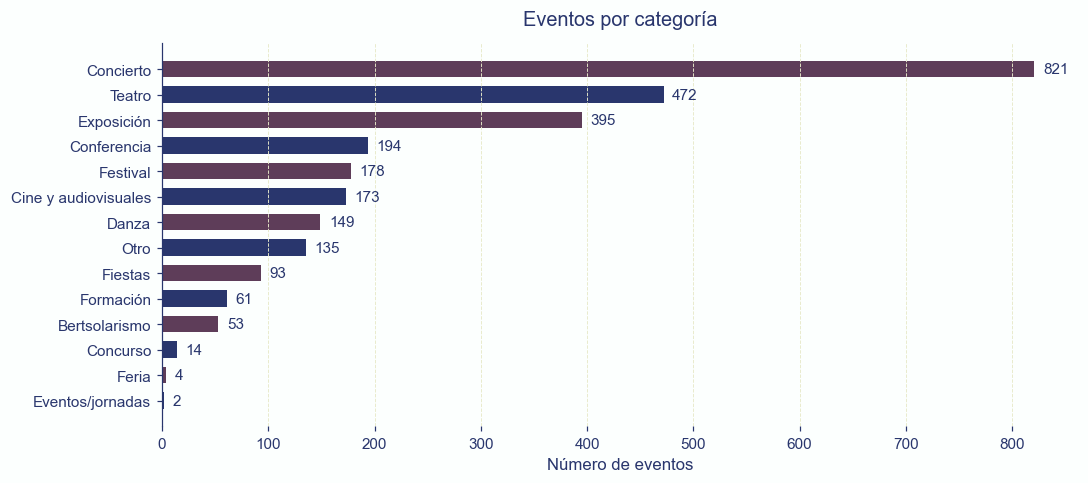

typeEs
Concierto               821
Teatro                  472
Exposición              395
Conferencia             194
Festival                178
Cine y audiovisuales    173
Danza                   149
Otro                    135
Fiestas                  93
Formación                61
Bertsolarismo            53
Concurso                 14
Feria                     4
Eventos/jornadas          2


In [38]:
tipos = df["typeEs"].value_counts()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(tipos.index[::-1], tipos.values[::-1],
        color=[COLOR_AZUL if i % 2 == 0 else COLOR_CIRUELA for i in range(len(tipos))],
        height=0.65)

for i, val in enumerate(tipos.values[::-1]):
    ax.text(val + 8, i, f"{val:,}", va="center", fontsize=10, color=COLOR_AZUL)

ax.set_xlabel("Número de eventos")
ax.set_title("Eventos por categoría", pad=12)
ax.spines[["top","right","bottom"]].set_visible(False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", linestyle="--")
fig.tight_layout()
plt.show()
print(tipos.to_string())


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
find

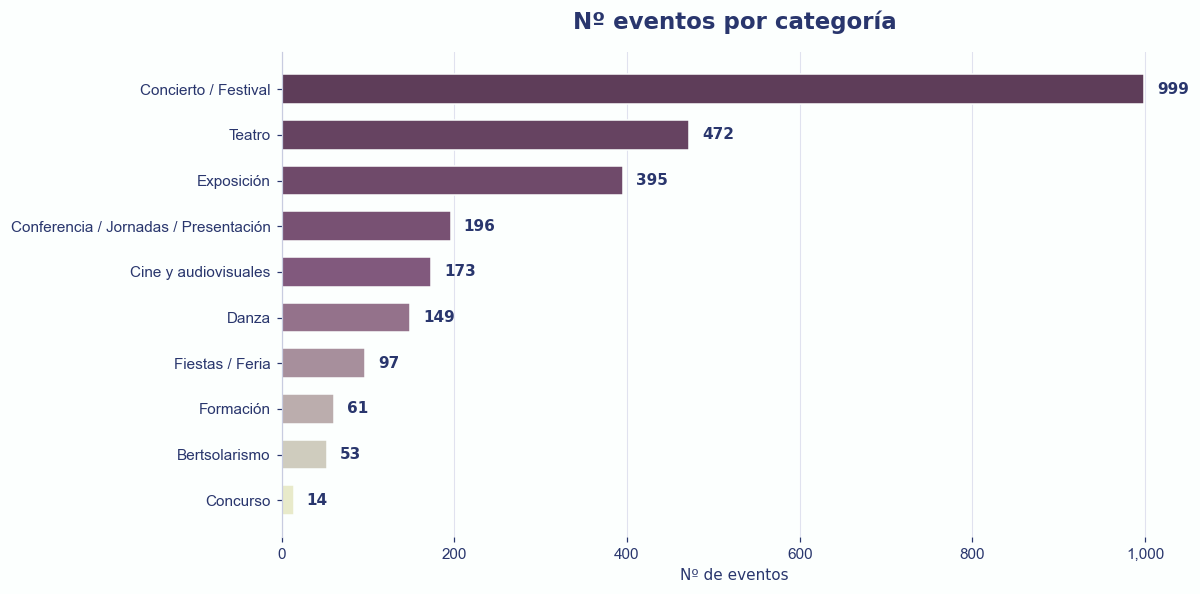

categoria_unificada
Concierto / Festival                     999
Teatro                                   472
Exposición                               395
Conferencia / Jornadas / Presentación    196
Cine y audiovisuales                     173
Danza                                    149
Fiestas / Feria                           97
Formación                                 61
Bertsolarismo                             53
Concurso                                  14


In [39]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import warnings

# Silenciamos advertencias de fuentes
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# ── BRANDING SUSTRAI ──────────────────────────────────────────
COLOR_AZUL     = '#29366d'  # Azul marino (Texto y título)
COLOR_CIRUELA  = '#5e3d59'  # Ciruela oscuro
COLOR_MALVA    = '#7f557b'  # Malva
COLOR_CREMA    = '#e8eaca'  # Crema claro
BG_COLOR       = '#fcfffe'  # Fondo casi blanco

TITLE_COLOR    = COLOR_AZUL
TEXT_COLOR     = COLOR_AZUL

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter', 'Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif']
plt.rcParams['text.color'] = TEXT_COLOR

# ── PROCESAMIENTO Y AGRUPACIÓN DE DATOS ────────────────────────
# Nuevo diccionario con las separaciones solicitadas
mapa_categorias = {
    'Concierto': 'Concierto / Festival',
    'Festival': 'Concierto / Festival',
    
    'Fiestas': 'Fiestas / Feria',
    'Feria': 'Fiestas / Feria',
    
    'Teatro': 'Teatro',
    'Danza': 'Danza',
    
    'Conferencia': 'Conferencia / Jornadas / Presentación',
    'Eventos/jornadas': 'Conferencia / Jornadas / Presentación',
    'Presentación': 'Conferencia / Jornadas / Presentación',
    
    'Cine y audiovisuales': 'Cine y audiovisuales',
    'Bertsolarismo': 'Bertsolarismo',
    'Exposición': 'Exposición',
    'Formación': 'Formación',
    'Concurso': 'Concurso'
}

# 1. Aplicamos el mapeo sobre la columna 'typeEs'
df['categoria_unificada'] = df['typeEs'].map(mapa_categorias)

# 2. Por seguridad con datos externos, agrupamos los no listados como 'Otros' y los quitamos si existen
df['categoria_unificada'] = df['categoria_unificada'].fillna('Otros')
tipos = df['categoria_unificada'].value_counts()
tipos = tipos.drop('Otros', errors='ignore')

# ── DISEÑO DEL GRÁFICO CON DEGRADADO DE ALTO CONTRASTE ─────────
fig, ax = plt.subplots(figsize=(11, 5.5), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

# Generamos un rango cromático amplio y bien diferenciado basado en tus colores de identidad:
# Desde Ciruela Oscuro pasando por Malva hasta el Crema Claro
base_colors = [
    '#5e3d59', '#664361', '#6f4a6a', '#785173', '#81597d', 
    '#94728b', '#a78f9c', '#bbadad', '#cfccbe', '#e8eaca'
]

# Recortamos la paleta al tamaño exacto de categorías y la invertimos para asociar el oscuro al valor más alto
colors_degradado = base_colors[:len(tipos)][::-1]

# Dibujamos las barras horizontales manteniendo las más altas arriba ([::-1])
ax.barh(tipos.index[::-1], tipos.values[::-1],
        color=colors_degradado, edgecolor=BG_COLOR, linewidth=1, height=0.65)

# Añadir las etiquetas de conteo al lado de cada barra de manera proporcional
max_val = tipos.max()
for i, val in enumerate(tipos.values[::-1]):
    ax.text(val + (max_val * 0.015), i, f"{val:,}", 
            va="center", ha="left", fontsize=10, color=TEXT_COLOR, fontweight='bold', fontname='Inter')

# Estilización de títulos y etiquetas de ejes
ax.set_xlabel("Nº de eventos", color=TEXT_COLOR, fontsize=10, fontname='Inter')
ax.set_title("Nº eventos por categoría", color=TITLE_COLOR, fontname='Italiana', fontsize=15, fontweight='bold', pad=15)

# Limpieza y pulido de ejes (Spines) al estilo Sustrai
ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.spines["left"].set_color('#c8cce0')
ax.tick_params(axis='both', colors=TEXT_COLOR, labelsize=10)

# Rejilla sutil de fondo y formateador de miles
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", linestyle="-", color='#e0e2ef', linewidth=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

print(tipos.to_string())

## 4. Distribución geográfica

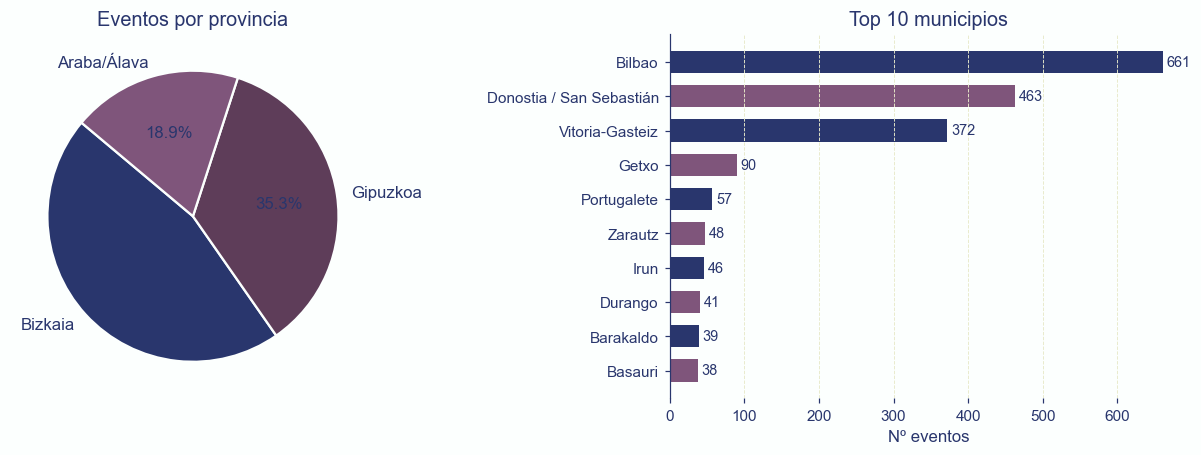

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Provincia
prov = df["province"].value_counts()
axes[0].pie(prov.values, labels=prov.index,
            colors=[COLOR_AZUL, COLOR_CIRUELA, COLOR_MALVA],
            autopct="%1.1f%%", startangle=140,
            wedgeprops={"linewidth": 1.5, "edgecolor": BG_COLOR},
            textprops={"fontsize": 11})
axes[0].set_title("Eventos por provincia")

# Top 10 municipios
muni = df["municipalityEs"].value_counts().head(10)
bar_colors = [COLOR_AZUL if i % 2 == 0 else COLOR_MALVA for i in range(len(muni))]
axes[1].barh(muni.index[::-1], muni.values[::-1], color=bar_colors[::-1], height=0.65)
for i, val in enumerate(muni.values[::-1]):
    axes[1].text(val + 5, i, f"{val:,}", va="center", fontsize=9.5, color=COLOR_AZUL)
axes[1].set_xlabel("Nº eventos")
axes[1].set_title("Top 10 municipios")
axes[1].spines[["top","right","bottom"]].set_visible(False)
axes[1].grid(axis="x", linestyle="--")

fig.tight_layout(pad=2)
plt.show()


findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not fo

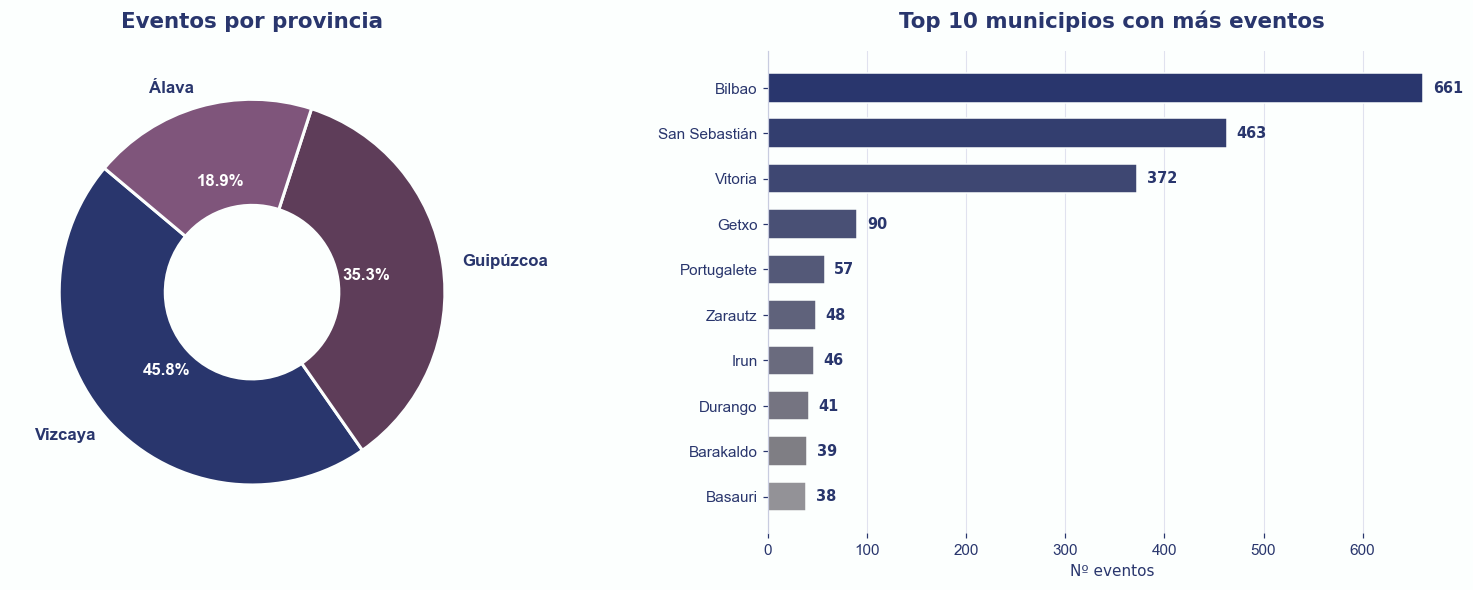

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import warnings

# Silenciamos advertencias de fuentes para limpiar la consola
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# ── BRANDING SUSTRAI ──────────────────────────────────────────
COLOR_AZUL     = '#29366d'  # Azul marino (Principal)
COLOR_CIRUELA  = '#5e3d59'  # Ciruela oscuro
COLOR_MALVA    = '#7f557b'  # Malva
BG_COLOR       = '#fcfffe'  # Fondo casi blanco

TITLE_COLOR    = COLOR_AZUL
TEXT_COLOR     = COLOR_AZUL

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter', 'Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif']
plt.rcParams['text.color'] = TEXT_COLOR

# ── FUNCIÓN DE LIMPIEZA AVANZADA POR TEXTO CONTENIDO ──────────
def limpiar_provincia(val):
    val_lower = str(val).lower()
    if 'alava' in val_lower or 'álava' in val_lower or 'araba' in val_lower:
        return 'Álava'
    elif 'guipuzcoa' in val_lower or 'guipúzcoa' in val_lower or 'gipuzkoa' in val_lower:
        return 'Guipúzcoa'
    elif 'vizcaya' in val_lower or 'bizkaia' in val_lower:
        return 'Vizcaya'
    return str(val).strip()

def limpiar_municipio(val):
    val_lower = str(val).lower()
    if 'bilbao' in val_lower or 'bilbo' in val_lower:
        return 'Bilbao'
    elif 'sebastian' in val_lower or 'sebastián' in val_lower or 'donostia' in val_lower:
        return 'San Sebastián'
    elif 'vitoria' in val_lower or 'gasteiz' in val_lower:
        return 'Vitoria'
    return str(val).strip()

# Aplicamos las funciones fila por fila
df['province_clean'] = df['province'].apply(limpiar_provincia)
df['municipality_clean'] = df['municipalityEs'].apply(limpiar_municipio)

# ── PROCESAMIENTO DE DATOS ────────────────────────────────────
prov = df["province_clean"].value_counts()
muni = df["municipality_clean"].value_counts().head(10)

# ── DISEÑO DEL SUBPLOT (1 Fila, 2 Columnas) ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG_COLOR)

# ── 1. GRÁFICO DE PROVINCIAS (DONUT ESTILIZADO) ───────────────
colors_prov = [COLOR_AZUL, COLOR_CIRUELA, COLOR_MALVA][:len(prov)]

wedges, texts, autotexts = axes[0].pie(
    prov.values, 
    labels=prov.index,
    colors=colors_prov,
    autopct="%1.1f%%", 
    startangle=140,
    wedgeprops={"linewidth": 2, "edgecolor": BG_COLOR, "width": 0.55},
    textprops={"fontsize": 11, "fontweight": "bold"}
)

# Forzar texto blanco en los porcentajes interiores para máxima legibilidad
for autotext in autotexts:
    autotext.set_color('white')

axes[0].set_title("Eventos por provincia", color=TITLE_COLOR, fontname='Italiana', fontsize=14, fontweight='bold', pad=15)


# ── 2. TOP 10 MUNICIPIOS (BARRA HORIZONTAL CON DEGRADADO) ─────
base_colors_muni = [
    '#29366d', '#333e6f', '#3e4772', '#495075', '#545978',
    '#5f627b', '#6a6b7e', '#757481', '#7f7e84', '#939297'
]
colors_degradado_muni = base_colors_muni[:len(muni)][::-1]

# Dibujamos las barras horizontales manteniendo el orden de mayor arriba ([::-1])
bars = axes[1].barh(muni.index[::-1], muni.values[::-1], color=colors_degradado_muni, edgecolor=BG_COLOR, height=0.65)

# Añadir las etiquetas de conteo al lado de cada barra de manera proporcional
max_val = muni.max()
for i, val in enumerate(muni.values[::-1]):
    axes[1].text(val + (max_val * 0.015), i, f"{val:,}", 
                 va="center", ha="left", fontsize=9.5, color=TEXT_COLOR, fontweight='bold', fontname='Inter')

axes[1].set_xlabel("Nº eventos", color=TEXT_COLOR, fontsize=10, fontname='Inter')
axes[1].set_title("Top 10 municipios con más eventos", color=TITLE_COLOR, fontname='Italiana', fontsize=14, fontweight='bold', pad=15)


# ── LIMPIEZA Y AJUSTES DE EJES (ESTILIZACIÓN) ─────────────────
axes[1].set_facecolor(BG_COLOR)
axes[1].tick_params(axis='both', colors=TEXT_COLOR, labelsize=10)

# Ocultamos bordes innecesarios y suavizamos la línea del eje Y
axes[1].spines[["top", "right", "bottom"]].set_visible(False)
axes[1].spines["left"].set_color('#c8cce0')

# Formateador de miles y rejilla sutil vertical
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].grid(axis="x", linestyle="-", color='#e0e2ef', linewidth=0.7)
axes[1].set_axisbelow(True)

fig.tight_layout(pad=3)
plt.show()

## 5. Temporalidad

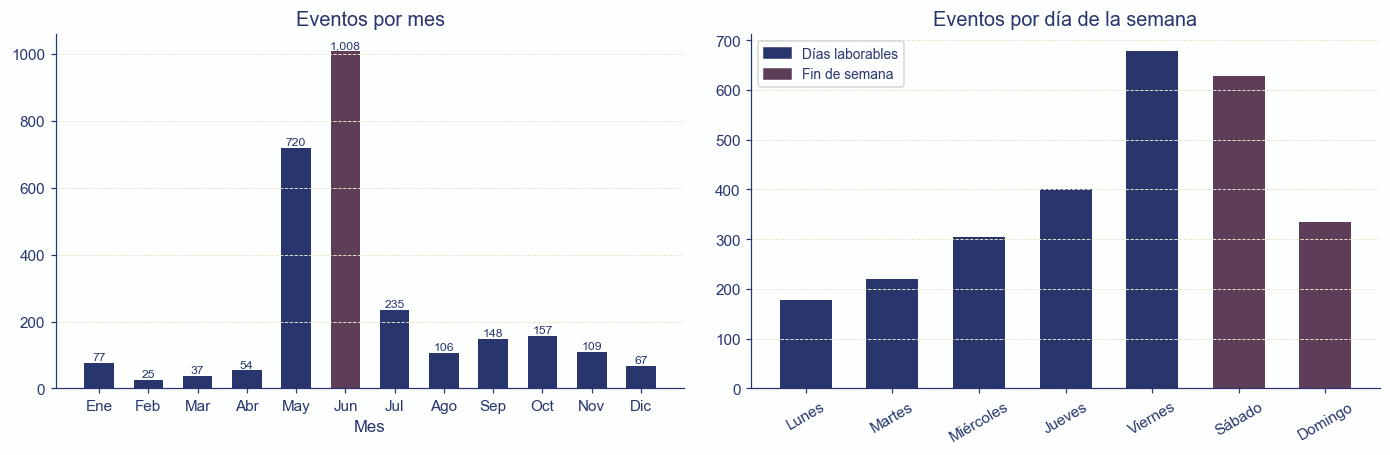

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Eventos por mes
mes_order  = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
mes_counts = df["mes_label"].value_counts().reindex(mes_order, fill_value=0)
axes[0].bar(mes_counts.index,
            mes_counts.values,
            color=[COLOR_CIRUELA if v == mes_counts.max() else COLOR_AZUL for v in mes_counts.values],
            width=0.6)
axes[0].set_title("Eventos por mes")
axes[0].set_xlabel("Mes")
axes[0].spines[["top","right"]].set_visible(False)
axes[0].grid(axis="y", linestyle="--")
for bar in axes[0].patches:
    if bar.get_height() > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                     f"{int(bar.get_height()):,}", ha="center", fontsize=8, color=COLOR_AZUL)

# Eventos por día de semana
dia_order  = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
dia_counts = df["weekday"].value_counts().reindex(dia_order, fill_value=0)
finde_col  = [COLOR_CIRUELA if d in ["Sábado","Domingo"] else COLOR_AZUL for d in dia_order]
axes[1].bar(dia_counts.index, dia_counts.values, color=finde_col, width=0.6)
axes[1].set_title("Eventos por día de la semana")
axes[1].tick_params(axis="x", rotation=30)
axes[1].spines[["top","right"]].set_visible(False)
axes[1].grid(axis="y", linestyle="--")

azul_p   = mpatches.Patch(color=COLOR_AZUL,    label="Días laborables")
cirue_p  = mpatches.Patch(color=COLOR_CIRUELA, label="Fin de semana")
axes[1].legend(handles=[azul_p, cirue_p], fontsize=9)

fig.tight_layout(pad=2)
plt.show()


findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfon

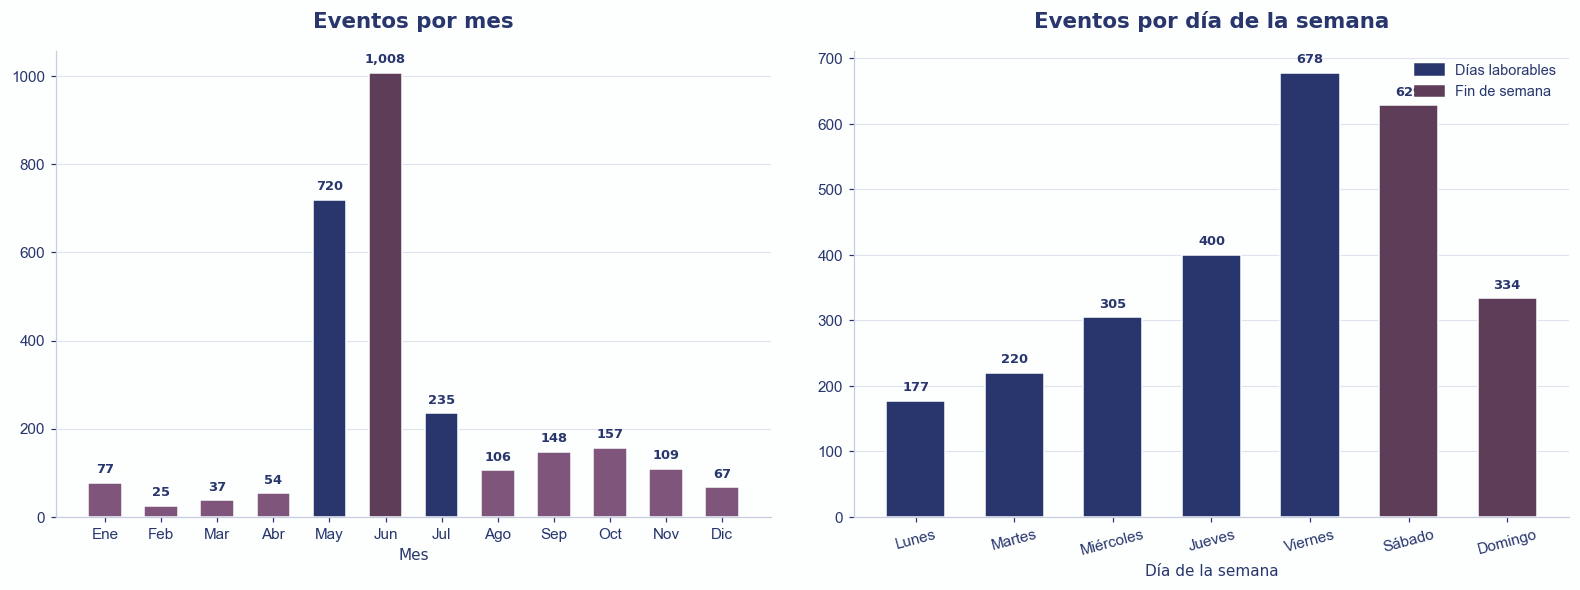

In [49]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import warnings

# Silenciamos advertencias de fuentes para limpiar la consola
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# ── BRANDING SUSTRAI ──────────────────────────────────────────
COLOR_AZUL     = '#29366d'  # Azul marino (Principal)
COLOR_CIRUELA  = '#5e3d59'  # Ciruela oscuro
COLOR_MALVA    = '#7f557b'  # Malva
BG_COLOR       = '#fcfffe'  # Fondo casi blanco crema (Ajustado de #fcffe)

TITLE_COLOR    = COLOR_AZUL
TEXT_COLOR     = COLOR_AZUL

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter', 'Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif']
plt.rcParams['text.color'] = TEXT_COLOR

# ── PREPARACIÓN DE FIGURA (1 Fila, 2 Columnas) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG_COLOR)

# ── 1. GRÁFICO: EVENTOS POR MES ───────────────────────────────
mes_order  = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
mes_counts = df["mes_label"].value_counts().reindex(mes_order, fill_value=0)

# Generamos un degradado cromático suave basado en la identidad de Sustrai
# El mes con mayor volumen recibirá el COLOR_CIRUELA de forma destacada
max_mes_val = mes_counts.max()
colors_meses = []
for v in mes_counts.values:
    if v == max_mes_val and max_mes_val > 0:
        colors_meses.append(COLOR_CIRUELA)
    else:
        # Transición tonal proporcional al volumen del mes usando Azul y Malva
        colors_meses.append(COLOR_AZUL if v > mes_counts.mean() else COLOR_MALVA)

bars_mes = axes[0].bar(mes_counts.index, mes_counts.values, color=colors_meses, edgecolor=BG_COLOR, width=0.6)

axes[0].set_title("Eventos por mes", color=TITLE_COLOR, fontname='Italiana', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel("Mes", color=TEXT_COLOR, fontsize=10, fontname='Inter')

# Añadir etiquetas de conteo sobre las barras de forma limpia
for bar in bars_mes:
    height = bar.get_height()
    if height > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, height + (max_mes_val * 0.015),
                     f"{int(height):,}", ha="center", va="bottom", fontsize=8.5, color=TEXT_COLOR, fontweight='bold', fontname='Inter')


# ── 2. GRÁFICO: EVENTOS POR DÍA DE LA SEMANA ──────────────────
dia_order  = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
dia_counts = df["weekday"].value_counts().reindex(dia_order, fill_value=0)

# El fin de semana destaca en Ciruela y los días laborables en Azul Marino
finde_col  = [COLOR_CIRUELA if d in ["Sábado","Domingo"] else COLOR_AZUL for d in dia_order]

bars_dias = axes[1].bar(dia_counts.index, dia_counts.values, color=finde_col, edgecolor=BG_COLOR, width=0.6)

axes[1].set_title("Eventos por día de la semana", color=TITLE_COLOR, fontname='Italiana', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Día de la semana", color=TEXT_COLOR, fontsize=10, fontname='Inter')
axes[1].tick_params(axis="x", rotation=15) # Rotación suavizada para mejor lectura

# Leyenda estilizada sin bordes invasivos
azul_p   = mpatches.Patch(color=COLOR_AZUL, label="Días laborables")
cirue_p  = mpatches.Patch(color=COLOR_CIRUELA, label="Fin de semana")
axes[1].legend(handles=[azul_p, cirue_p], fontsize=9.5, frameon=False, loc="upper right")

# Añadir etiquetas de conteo sobre las barras del segundo gráfico
max_dia_val = dia_counts.max()
for bar in bars_dias:
    height = bar.get_height()
    if height > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, height + (max_dia_val * 0.015),
                     f"{int(height):,}", ha="center", va="bottom", fontsize=8.5, color=TEXT_COLOR, fontweight='bold', fontname='Inter')


# ── LIMPIEZA Y ACABADO DE EJES (ESTILO SUSTRAI) ───────────────
for ax in axes:
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(axis='both', colors=TEXT_COLOR, labelsize=10)
    
    # Ocultamos bordes innecesarios (Spines)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color('#c8cce0')
    
    # Rejilla horizontal sutil
    ax.yaxis.grid(True, color='#e0e2ef', linewidth=0.7, linestyle='-')
    ax.set_axisbelow(True)

fig.tight_layout(pad=3)
plt.show()

findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfon

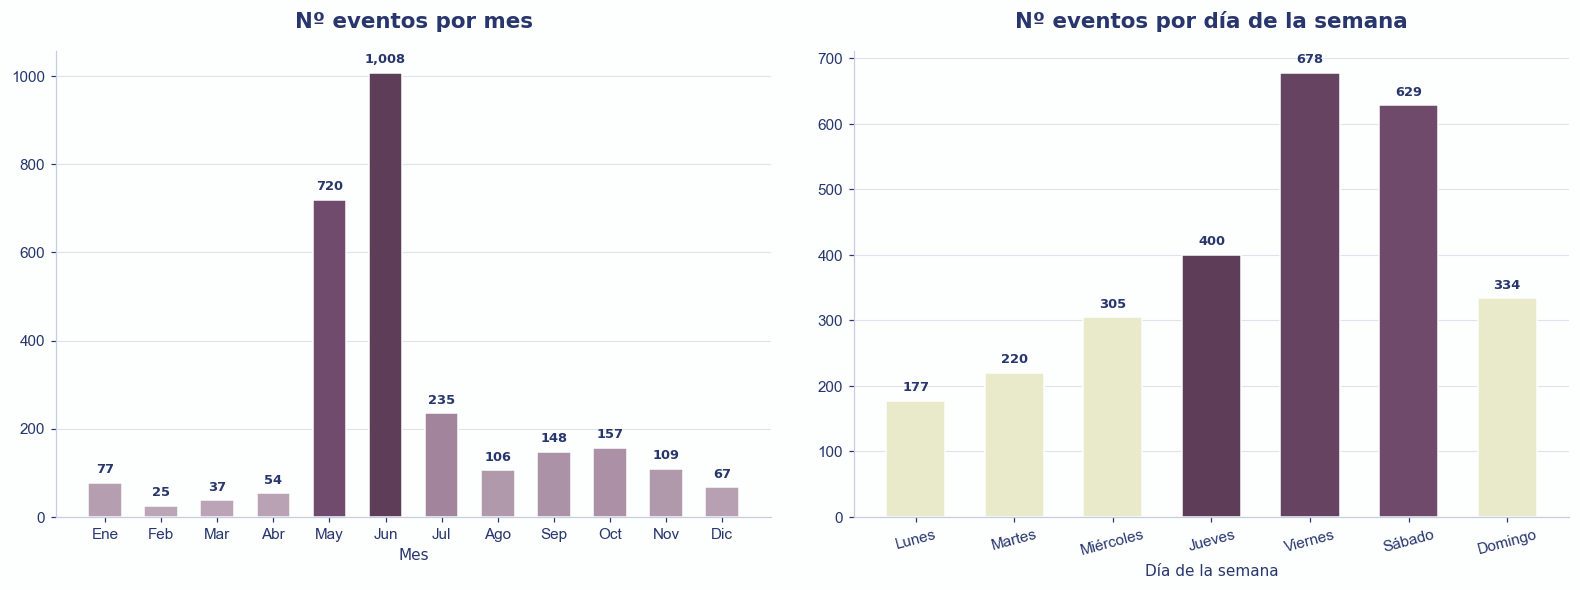

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
from matplotlib.colors import LinearSegmentedColormap

# Silenciamos advertencias de fuentes para limpiar la consola
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# ── BRANDING SUSTRAI ──────────────────────────────────────────
COLOR_AZUL     = '#29366d'  # Azul marino (Texto y títulos)
COLOR_CIRUELA  = '#5e3d59'  # Ciruela oscuro (Pico máximo de eventos)
COLOR_MALVA    = '#7f557b'  # Malva (Eventos medios)
COLOR_CREMA    = '#e8eaca'  # Crema claro (Para días fuera del top 3)
BG_COLOR       = '#fcfffe'  # Fondo casi blanco crema de la app

TITLE_COLOR    = COLOR_AZUL
TEXT_COLOR     = COLOR_AZUL

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter', 'Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif']
plt.rcParams['text.color'] = TEXT_COLOR

# ── CONFIGURACIÓN DEL LIENZO (1 Fila, 2 Columnas) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=BG_COLOR)


# ── 1. GRÁFICO: EVENTOS POR MES (DEGRADADO REAL PROPORCIONAL) ──
mes_order  = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
mes_counts = df["mes_label"].value_counts().reindex(mes_order, fill_value=0)

# Creamos un mapa de color personalizado que vaya desde un tono suave hasta el Ciruela Oscuro de Sustrai
cmap_sustrai = LinearSegmentedColormap.from_list("SustraiMeses", ['#bba6b6', COLOR_MALVA, COLOR_CIRUELA])

max_mes_val = mes_counts.max()
min_mes_val = mes_counts.min()

# Generamos los colores mapeando la altura de cada barra de forma cronológica exacta
colors_meses = []
for v in mes_counts.values:
    if max_mes_val == min_mes_val:
        # Si todos los meses tienen el mismo número de eventos, usamos el malva por defecto
        colors_meses.append(COLOR_MALVA)
    else:
        # Calculamos una posición entre 0.0 y 1.0 según el volumen de eventos del mes
        proporcion = (v - min_mes_val) / (max_mes_val - min_mes_val)
        colors_meses.append(cmap_sustrai(proporcion))

bars_mes = axes[0].bar(mes_counts.index, mes_counts.values, color=colors_meses, edgecolor=BG_COLOR, width=0.6)

axes[0].set_title("Nº eventos por mes", color=TITLE_COLOR, fontname='Italiana', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel("Mes", color=TEXT_COLOR, fontsize=10, fontname='Inter')

# Añadir etiquetas de conteo numérico sobre las barras de los meses
for bar in bars_mes:
    height = bar.get_height()
    if height > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, height + (max_mes_val * 0.015),
                     f"{int(height):,}", ha="center", va="bottom", fontsize=8.5, color=TEXT_COLOR, fontweight='bold', fontname='Inter')


# ── 2. GRÁFICO: EVENTOS POR DÍA DE LA SEMANA (DESTACANDO TOP 3) ──
dia_order  = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
dia_counts = df["weekday"].value_counts().reindex(dia_order, fill_value=0)

# Identificamos cuáles son los 3 valores más altos del gráfico para el podio
top3_valores = sorted(dia_counts.values, reverse=True)[:3]

# Asignamos colores: degradado de tu paleta para el Top 3, crema claro para los 4 restantes
colors_dias = []
top3_idx = 0 
colores_podio = ['#5e3d59', '#664361', '#6f4a6a'] # Rango fuerte de tu paleta de alto contraste

for v in dia_counts.values:
    if v in top3_valores and v > 0:
        colors_dias.append(colores_podio[top3_idx])
        top3_idx += 1
    else:
        colors_dias.append(COLOR_CREMA) # El resto pasa a un segundo plano limpio

bars_dias = axes[1].bar(dia_counts.index, dia_counts.values, color=colors_dias, edgecolor=BG_COLOR, width=0.6)

axes[1].set_title("Nº eventos por día de la semana", color=TITLE_COLOR, fontname='Italiana', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Día de la semana", color=TEXT_COLOR, fontsize=10, fontname='Inter')
axes[1].tick_params(axis="x", rotation=15)

# Añadir etiquetas de conteo numérico sobre las barras de los días
max_dia_val = dia_counts.max()
for bar in bars_dias:
    height = bar.get_height()
    if height > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, height + (max_dia_val * 0.015),
                     f"{int(height):,}", ha="center", va="bottom", fontsize=8.5, color=TEXT_COLOR, fontweight='bold', fontname='Inter')


# ── LIMPIEZA GENERAL DE EJES Y BORDES (ESTILO SUSTRAI) ────────
for ax in axes:
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(axis='both', colors=TEXT_COLOR, labelsize=10)
    
    # Ocultamos los bordes superior y derecho para dar un look minimalista
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color('#c8cce0')
    
    # Rejilla horizontal limpia por detrás de las barras
    ax.yaxis.grid(True, color='#e0e2ef', linewidth=0.7, linestyle='-')
    ax.set_axisbelow(True)

fig.tight_layout(pad=3)
plt.show()

## 6. Heatmap: tipo de evento × mes

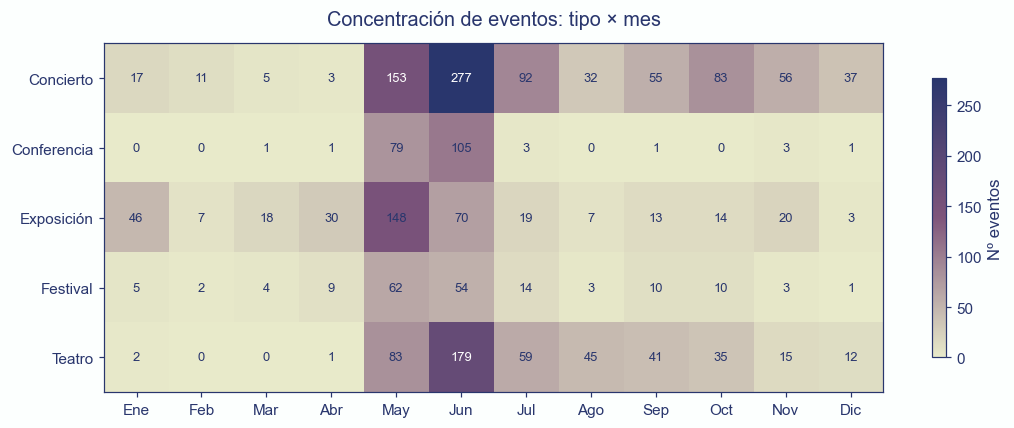

In [43]:
import matplotlib.colors as mcolors

top5  = df["typeEs"].value_counts().head(5).index
pivot = (df[df["typeEs"].isin(top5)]
         .groupby(["month","typeEs"])
         .size()
         .unstack(fill_value=0))
pivot.index = [MESES.get(m, m) for m in pivot.index]
pivot = pivot.reindex([MESES[i] for i in range(1,13) if MESES[i] in pivot.index])

# Colormap personalizado con la paleta Sustrai
cmap = mcolors.LinearSegmentedColormap.from_list(
    "sustrai", [COLOR_CREMA, COLOR_MALVA, COLOR_AZUL])

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot.values.T, aspect="auto", cmap=cmap)
ax.set_xticks(range(len(pivot.index)));   ax.set_xticklabels(pivot.index, fontsize=10)
ax.set_yticks(range(len(pivot.columns))); ax.set_yticklabels(pivot.columns, fontsize=10)
ax.set_title("Concentración de eventos: tipo × mes", pad=12)

for i in range(len(pivot.columns)):
    for j in range(len(pivot.index)):
        v = pivot.values[j, i]
        txt_color = "white" if v > pivot.values.max() * 0.55 else COLOR_AZUL
        ax.text(j, i, str(v), ha="center", va="center", fontsize=8.5, color=txt_color)

plt.colorbar(im, ax=ax, label="Nº eventos", shrink=0.8)
fig.tight_layout()
plt.show()


## 7. Análisis de precios

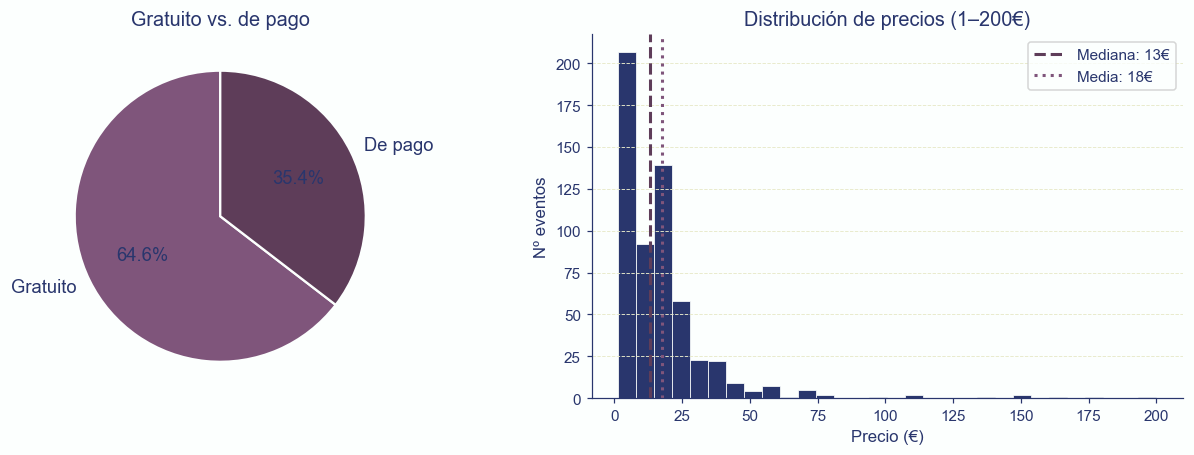

Precio mediano: 13.00€
Precio medio:   17.73€
Rango:          1.53€ – 200.00€


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Gratuito / De pago
free_counts = df["is_free"].value_counts()
axes[0].pie([free_counts.get(True,0), free_counts.get(False,0)],
            labels=["Gratuito", "De pago"],
            colors=[COLOR_MALVA, COLOR_CIRUELA],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"linewidth":1.5,"edgecolor":BG_COLOR},
            textprops={"fontsize":12})
axes[0].set_title("Gratuito vs. de pago")

# Histograma de precios
precios = df[df["price_eur"].between(1, 200)]["price_eur"]
axes[1].hist(precios, bins=30, color=COLOR_AZUL, edgecolor=BG_COLOR, linewidth=0.5)
axes[1].axvline(precios.median(), color=COLOR_CIRUELA, linewidth=2,
                linestyle="--", label=f"Mediana: {precios.median():.0f}€")
axes[1].axvline(precios.mean(), color=COLOR_MALVA, linewidth=2,
                linestyle=":", label=f"Media: {precios.mean():.0f}€")
axes[1].set_xlabel("Precio (€)")
axes[1].set_ylabel("Nº eventos")
axes[1].set_title("Distribución de precios (1–200€)")
axes[1].spines[["top","right"]].set_visible(False)
axes[1].grid(axis="y", linestyle="--")
axes[1].legend()

fig.tight_layout(pad=2)
plt.show()

print(f"Precio mediano: {precios.median():.2f}€")
print(f"Precio medio:   {precios.mean():.2f}€")
print(f"Rango:          {precios.min():.2f}€ – {precios.max():.2f}€")


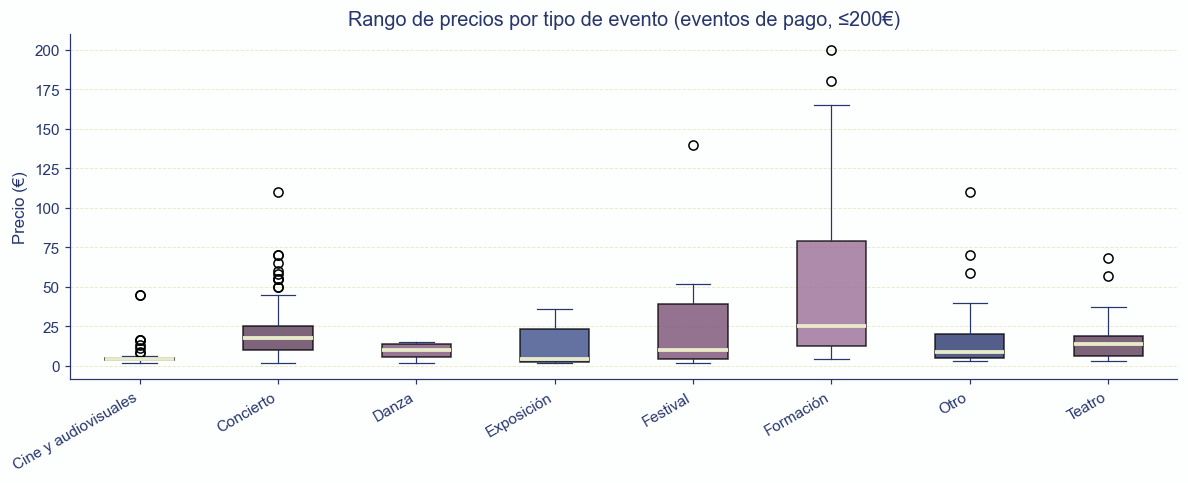

In [45]:
# Boxplot precio por tipo
tipos_precio = (df[df["price_eur"].between(1,200)]
                .groupby("typeEs")["price_eur"]
                .apply(list))
tipos_precio = tipos_precio[tipos_precio.apply(len) > 5].sort_index()

box_colors = [COLOR_AZUL, COLOR_CIRUELA, COLOR_MALVA,
              '#3d4f8a', '#7a5075', '#9b6e96']

fig, ax = plt.subplots(figsize=(11, 4.5))
bp = ax.boxplot(tipos_precio.values, patch_artist=True, notch=False,
                medianprops={"color": COLOR_CREMA, "linewidth": 2.5})
for patch, color in zip(bp["boxes"], box_colors * 4):
    patch.set_facecolor(color)
    patch.set_alpha(0.80)
for element in ["whiskers","caps","fliers"]:
    for item in bp[element]:
        item.set(color=COLOR_AZUL, linewidth=0.8)

ax.set_xticks(range(1, len(tipos_precio)+1))
ax.set_xticklabels(tipos_precio.index, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Precio (€)")
ax.set_title("Rango de precios por tipo de evento (eventos de pago, ≤200€)")
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", linestyle="--")
fig.tight_layout()
plt.show()


## 8. Idioma de los eventos

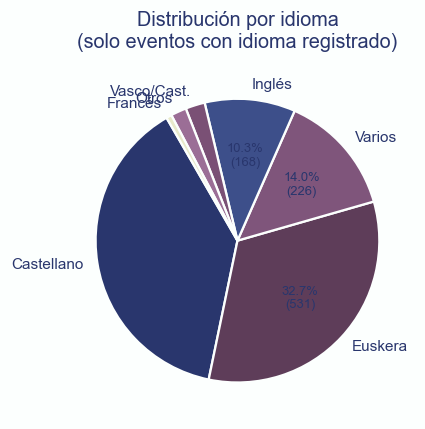

Eventos sin idioma registrado: 1,117 (40.7%)


In [46]:
lang = df["lang_label"].value_counts().dropna()

colors_lang = [COLOR_AZUL, COLOR_CIRUELA, COLOR_MALVA,
               '#3d4f8a', '#7a5075', '#9b6e96', COLOR_CREMA]

fig, ax = plt.subplots(figsize=(8, 4))
wedges, texts, autotexts = ax.pie(
    lang.values, labels=lang.index,
    colors=colors_lang[:len(lang)],
    autopct=lambda p: f"{p:.1f}%\n({int(p/100*lang.sum()):,})" if p > 3 else "",
    startangle=120,
    wedgeprops={"linewidth":1.5,"edgecolor":BG_COLOR},
    textprops={"fontsize":10}
)
for at in autotexts:
    at.set_fontsize(8.5)
ax.set_title("Distribución por idioma\n(solo eventos con idioma registrado)", pad=10)
fig.tight_layout()
plt.show()

print(f"Eventos sin idioma registrado: {df['language'].isnull().sum():,} "
      f"({df['language'].isnull().mean()*100:.1f}%)")


findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.


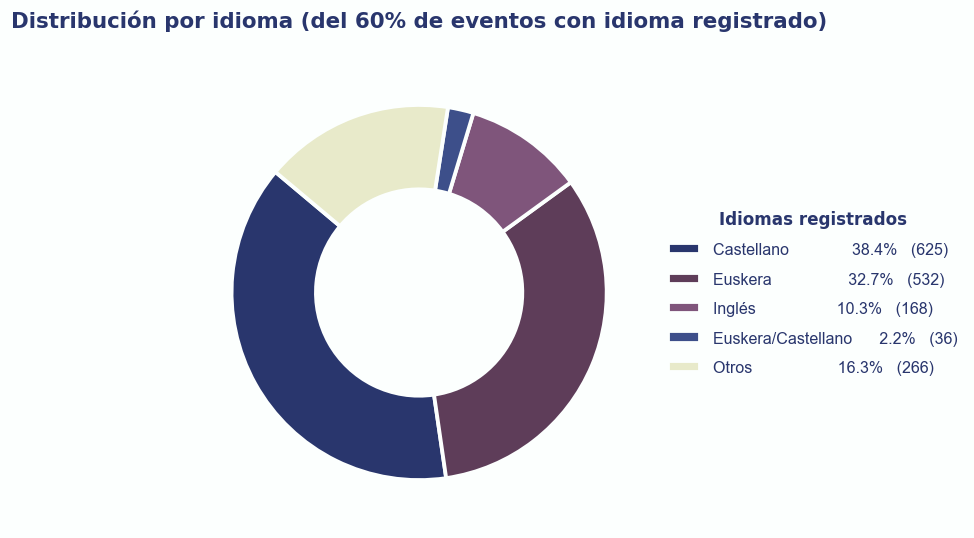

lang_clean
Castellano            625
Euskera               532
Inglés                168
Euskera/Castellano     36
Otros                 266


In [67]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# Silenciamos advertencias de fuentes para mantener la consola limpia
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# ── BRANDING SUSTRAI ──────────────────────────────────────────
COLOR_AZUL     = '#29366d'  # Azul marino (Principal)[cite: 1]
COLOR_CIRUELA  = '#5e3d59'  # Ciruela oscuro[cite: 1]
COLOR_MALVA    = '#7f557b'  # Malva[cite: 1]
COLOR_CREMA    = '#e8eaca'  # Crema claro (Para el grupo 'Otros')[cite: 1]
BG_COLOR       = '#fcfffe'  # Fondo casi blanco crema de la app[cite: 1]

TITLE_COLOR    = COLOR_AZUL
TEXT_COLOR     = COLOR_AZUL

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter', 'Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif']
plt.rcParams['text.color'] = TEXT_COLOR

# ── FILTRADO Y AGRUPACIÓN ESTRICTA DE IDIOMAS ─────────────────
# 1. Eliminamos los nulos reales de la columna de origen
df_idiomas = df[df['lang_label'].notnull()].copy()

# 2. Pasamos a minúsculas y limpiamos espacios para evitar duplicados por formato
df_idiomas['lang_clean'] = df_idiomas['lang_label'].astype(str).str.strip().str.lower()

# 3. Función de mapeo para forzar los 5 grupos solicitados
def clasificar_idioma(val):
    if val in ['castellano']:
        return 'Castellano'
    elif val in ['euskera', 'vasco']:
        return 'Euskera'
    elif val in ['euskera/cast.', 'euskera/castellano', 'vasco/cast.']:
        return 'Euskera/Castellano'
    elif val in ['inglés', 'ingles']:
        return 'Inglés'
    else:
        return 'Otros'

# Aplicamos la clasificación
df_idiomas['lang_clean'] = df_idiomas['lang_clean'].apply(clasificar_idioma)

# 4. Conteo final ordenado por volumen para el orden de las porciones del gráfico
lang_final = df_idiomas['lang_clean'].value_counts()

# Reordenamos para que 'Otros' quede al final por consistencia visual
if 'Otros' in lang_final.index:
    otros_series = lang_final.loc[['Otros']]
    lang_final = pd.concat([lang_final.drop('Otros'), otros_series])

total_validos = lang_final.sum()

# ── DISEÑO DEL GRÁFICO PREMIUM (ESTILO SUSTRAI) ────────────────
fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

# Colores asignados con intención de diseño: 4 tonos de marca + Crema para cajón de sastre
colors_pie = [COLOR_AZUL, COLOR_CIRUELA, COLOR_MALVA, '#3d4f8a', COLOR_CREMA][:len(lang_final)]

# Dibujamos el donut completamente limpio de textos internos
wedges, texts = ax.pie(
    lang_final.values, 
    startangle=140,
    colors=colors_pie,
    labels=None, 
    wedgeprops={"linewidth": 2.5, "edgecolor": BG_COLOR, "width": 0.45} # Estilo donut minimalista
)

# Creamos las etiquetas de la leyenda alineadas perfectamente
legend_labels = []
for idioma, valor in lang_final.items():
    porcentaje = (valor / total_validos) * 100
    legend_labels.append(f"{idioma:<22}  {porcentaje:.1f}%   ({valor:,})")

# Añadimos la leyenda lateral sin marcos invasivos
ax.legend(
    wedges, 
    legend_labels,
    title="Idiomas registrados",
    title_fontproperties={'weight': 'bold', 'size': 11, 'family': 'Inter'},
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    frameon=False,
    fontsize=10.5,
    labelspacing=0.9
)

# Título corporativo
ax.set_title("Distribución por idioma (del 60% de eventos con idioma registrado)", 
             color=TITLE_COLOR, fontname='Italiana', fontsize=14, fontweight='bold', pad=20, loc='center')

plt.tight_layout()
plt.show()

# Conteo por consola para verificación rápida
print(lang_final.to_string())

findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Italiana' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.
findfont: Font family 'Inter' not found.


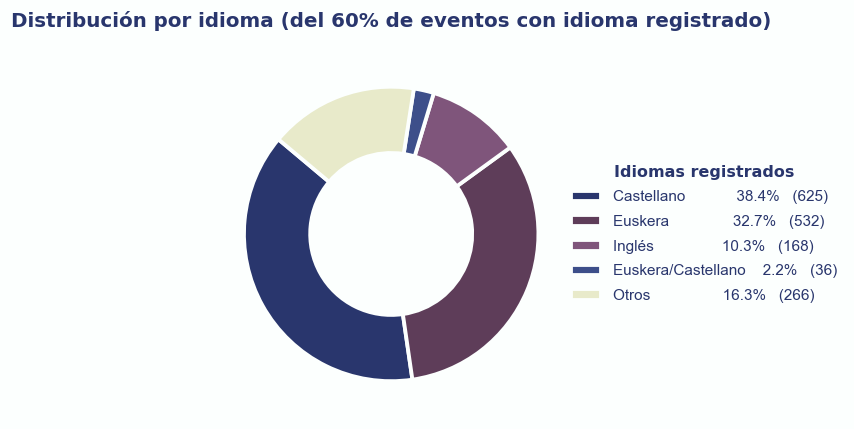

lang_clean
Castellano            625
Euskera               532
Inglés                168
Euskera/Castellano     36
Otros                 266


In [68]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# Silenciamos advertencias de fuentes para mantener la consola limpia
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

# ── BRANDING SUSTRAI ──────────────────────────────────────────
COLOR_AZUL     = '#29366d'  # Azul marino (Principal)
COLOR_CIRUELA  = '#5e3d59'  # Ciruela oscuro
COLOR_MALVA    = '#7f557b'  # Malva
COLOR_CREMA    = '#e8eaca'  # Crema claro (Para el grupo 'Otros')
BG_COLOR       = '#fcfffe'  # Fondo casi blanco crema de la app

TITLE_COLOR    = COLOR_AZUL
TEXT_COLOR     = COLOR_AZUL

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Inter', 'Arial', 'Helvetica', 'DejaVu Sans', 'sans-serif']
plt.rcParams['text.color'] = TEXT_COLOR

# ── FILTRADO Y AGRUPACIÓN ESTRICTA DE IDIOMAS ─────────────────
# 1. Eliminamos los nulos reales de la columna de origen
df_idiomas = df[df['lang_label'].notnull()].copy()

# 2. Pasamos a minúsculas y limpiamos espacios para evitar duplicados por formato
df_idiomas['lang_clean'] = df_idiomas['lang_label'].astype(str).str.strip().str.lower()

# 3. Función de mapeo para forzar los 5 grupos solicitados
def clasificar_idioma(val):
    if val in ['castellano']:
        return 'Castellano'
    elif val in ['euskera', 'vasco']:
        return 'Euskera'
    elif val in ['euskera/cast.', 'euskera/castellano', 'vasco/cast.']:
        return 'Euskera/Castellano'
    elif val in ['inglés', 'ingles']:
        return 'Inglés'
    else:
        return 'Otros'

# Aplicamos la clasificación
df_idiomas['lang_clean'] = df_idiomas['lang_clean'].apply(clasificar_idioma)

# 4. Conteo final ordenado por volumen para el orden de las porciones del gráfico
lang_final = df_idiomas['lang_clean'].value_counts()

# Reordenamos para que 'Otros' quede al final por consistencia visual
if 'Otros' in lang_final.index:
    otros_series = lang_final.loc[['Otros']]
    lang_final = pd.concat([lang_final.drop('Otros'), otros_series])

total_validos = lang_final.sum()

# ── DISEÑO DEL GRÁFICO PREMIUM COMPACTADO (ESTILO SUSTRAI) ─────
# Se reduce el figsize para comprimir el espacio sobrante en los bordes
fig, ax = plt.subplots(figsize=(8.5, 4), facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)

# Colores asignados: 4 tonos de marca + Crema para el grupo 'Otros'
colors_pie = [COLOR_AZUL, COLOR_CIRUELA, COLOR_MALVA, '#3d4f8a', COLOR_CREMA][:len(lang_final)]

# Dibujamos el donut completamente limpio de textos internos
wedges, texts = ax.pie(
    lang_final.values, 
    startangle=140,
    colors=colors_pie,
    labels=None, 
    wedgeprops={"linewidth": 2.5, "edgecolor": BG_COLOR, "width": 0.45}
)

# Creamos las etiquetas de la leyenda unificando el formato
legend_labels = []
for idioma, valor in lang_final.items():
    porcentaje = (valor / total_validos) * 100
    legend_labels.append(f"{idioma:<20}  {porcentaje:.1f}%   ({valor:,})")

# Se acerca la leyenda al gráfico usando bbox_to_anchor=(0.95, 0.5) para eliminar huecos
ax.legend(
    wedges, 
    legend_labels,
    title="Idiomas registrados",
    title_fontproperties={'weight': 'bold', 'size': 10.5, 'family': 'Inter'},
    loc="center left",
    bbox_to_anchor=(0.95, 0.5),
    frameon=False,
    fontsize=10,
    labelspacing=0.7  # Espaciado vertical ligeramente más compacto entre filas
)

# Título centrado
ax.set_title("Distribución por idioma (del 60% de eventos con idioma registrado)", 
             color=TITLE_COLOR, fontname='Italiana', fontsize=13, fontweight='bold', pad=15, loc='center')

plt.tight_layout()
plt.show()

# Conteo por consola
print(lang_final.to_string())

## 9. Gratuito vs. de pago por tipo de evento

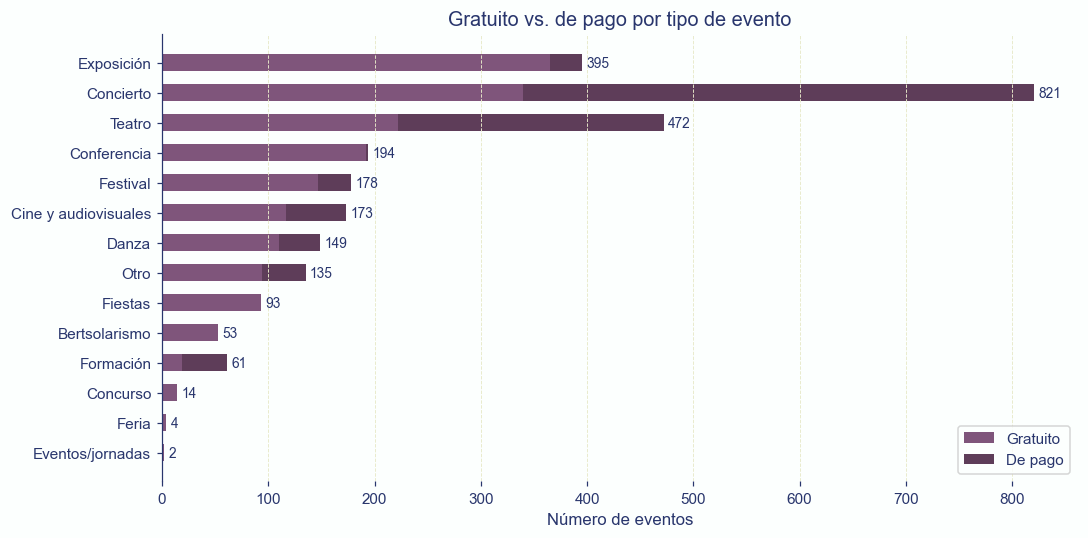

In [47]:
cross = df.groupby(["typeEs","is_free"]).size().unstack(fill_value=0)
cross.columns = ["De pago","Gratuito"]
cross = cross.sort_values("Gratuito", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cross.index, cross["Gratuito"], color=COLOR_MALVA,   label="Gratuito", height=0.55)
ax.barh(cross.index, cross["De pago"],  color=COLOR_CIRUELA, label="De pago",
        left=cross["Gratuito"], height=0.55)

for i, (g, p) in enumerate(zip(cross["Gratuito"], cross["De pago"])):
    total = g + p
    if total > 0:
        ax.text(total + 4, i, f"{total:,}", va="center", fontsize=9, color=COLOR_AZUL)

ax.set_xlabel("Número de eventos")
ax.set_title("Gratuito vs. de pago por tipo de evento")
ax.spines[["top","right","bottom"]].set_visible(False)
ax.grid(axis="x", linestyle="--")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()


## 10. Resumen ejecutivo

In [48]:
total    = len(df)
gratuito = df["is_free"].sum()
pago     = total - gratuito
n_muni   = df["municipalityEs"].nunique()
top_tipo = df["typeEs"].value_counts().idxmax()
top_muni = df["municipalityEs"].value_counts().idxmax()
top_mes  = df["mes_label"].value_counts().idxmax()
top_dia  = df["weekday"].value_counts().idxmax()
p_median = df[df["price_eur"].between(1,200)]["price_eur"].median()

print("=" * 52)
print("  RESUMEN EDA · KULTURKLIK · PROYECTO SUSTRAI")
print("=" * 52)
print(f"  Total eventos analizados   : {total:>6,}")
print(f"  Municipios representados   : {n_muni:>6,}")
print(f"  Eventos gratuitos          : {gratuito:>6,}  ({gratuito/total*100:.1f}%)")
print(f"  Eventos de pago            : {pago:>6,}  ({pago/total*100:.1f}%)")
print(f"  Precio mediano (de pago)   :  {p_median:>5.0f}€")
print(f"  Tipo más frecuente         : {top_tipo}")
print(f"  Municipio con más eventos  : {top_muni}")
print(f"  Mes con más actividad      : {top_mes}")
print(f"  Día con más eventos        : {top_dia}")
print("=" * 52)


  RESUMEN EDA · KULTURKLIK · PROYECTO SUSTRAI
  Total eventos analizados   :  2,744
  Municipios representados   :    178
  Eventos gratuitos          :  1,772  (64.6%)
  Eventos de pago            :    972  (35.4%)
  Precio mediano (de pago)   :     13€
  Tipo más frecuente         : Concierto
  Municipio con más eventos  : Bilbao
  Mes con más actividad      : Jun
  Día con más eventos        : Viernes
